In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("AirQualityUCI.csv")

print(df.head())
print(df.shape)
print(df.info())

        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  10/3/2004  18.00.00     2.6         1360     150.0      11.9   
1  10/3/2004  19.00.00     2.0         1292     112.0       9.4   
2  10/3/2004  20.00.00     2.2         1402      88.0       9.0   
3  10/3/2004  21.00.00     2.2         1376      80.0       9.2   
4  10/3/2004  22.00.00     1.6         1272      51.0       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0           1046      166          1056      113          1692       1268.0   
1            955      103          1174       92          1559        972.0   
2            939      131          1140      114          1555       1074.0   
3            948      172          1092      122          1584       1203.0   
4            836      131          1205      116          1490       1110.0   

      T    RH      AH  
0  13.6  48.9  0.7578  
1  13.3  47.7  0.7255  
2  11.9  54.0  0.7502  
3  11.0  60.0  0.7867  
4 

In [9]:
#Convert sensor columns to numeric
for column in df.columns :
    if column not in ["Date", "Time"]:
        df[column] = pd.to_numeric(df[column], errors="coerce")
        
# Replace -200 with NaN
df = df.replace(-200, np.nan)

print(df.isnull().sum())
        

Date                0
Time                0
CO(GT)           1682
PT08.S1(CO)       367
NMHC(GT)         8442
C6H6(GT)          366
PT08.S2(NMHC)     367
NOx(GT)          1638
PT08.S3(NOx)      367
NO2(GT)          1641
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                367
dtype: int64


In [10]:
datetime = pd.to_datetime(
    df["Date"] + " " + df["Time"].astype(str).str.replace(".",":", regex=False),
    dayfirst=True,
    errors="coerce"
)

df ["hour"] = datetime.dt.hour
df["day_of_week"] = datetime.dt.dayofweek
df["month"] = datetime.dt.month

print(df[["Date", "Time", "hour", "day_of_week", "month"]].head())

        Date      Time  hour  day_of_week  month
0  10/3/2004  18.00.00  18.0          2.0    3.0
1  10/3/2004  19.00.00  19.0          2.0    3.0
2  10/3/2004  20.00.00  20.0          2.0    3.0
3  10/3/2004  21.00.00  21.0          2.0    3.0
4  10/3/2004  22.00.00  22.0          2.0    3.0


In [11]:
target = "CO(GT)"

features = [
    column for column in df.columns
    if column not in ["Date", "Time", target]
]

print("Features:")
print(features)


Features:
['PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'hour', 'day_of_week', 'month']


In [12]:
model_df = df[features + [target]]

# Remove rows wehere our target is missing
model_df = model_df.dropna(subset=[target])

X = model_df[features]
y = model_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (7675, 15)
y shape: (7675,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (6140, 15)
Testing data: (1535, 15)


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    
    ("regressor", HistGradientBoostingRegressor(
        max_iter=350,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        loss="absolute_error",
        random_state=42
    ))
])

In [15]:
model.fit(X_train, y_train)

print("Model training completed!")


Model training completed!


In [16]:
predictions = model.predict(X_test)

print(predictions[:10])


[6.49690855 0.90898859 2.59431018 1.84346335 0.86736736 2.38623906
 4.31508338 1.45852829 3.00132947 3.78567038]


In [17]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_squared_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.12703437885649185
RMSE: 0.35641882505907546
R2: 0.9389683941301588


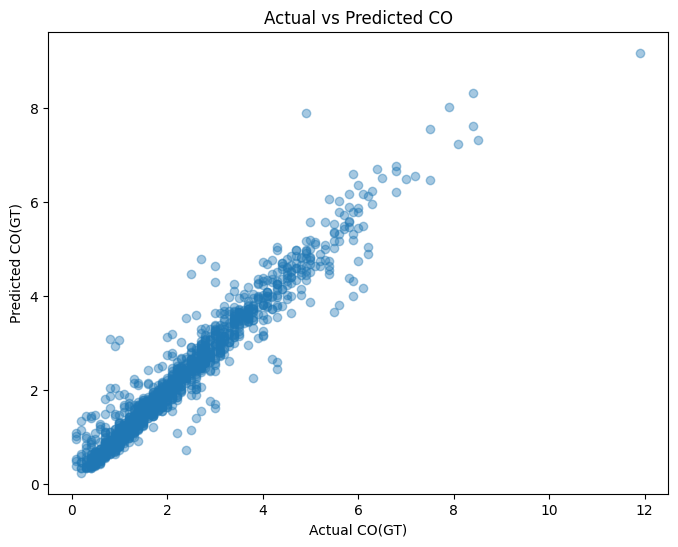

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.4
)

plt.xlabel("Actual CO(GT)")
plt.ylabel("Predicted CO(GT)")
plt.title("Actual vs Predicted CO")

plt.show()


In [20]:
import joblib

joblib.dump(
    model,
    "air_quality_co_model.joblib"
)

print("Model saved!")

Model saved!
